In [113]:
import pandas as pd

data_quality=pd.read_csv("../raw_data/quality.csv")
data_production=pd.read_csv("../raw_data/production_b001.csv")


merged_data=pd.merge(data_production,data_quality,on='Cell_ID')
print(merged_data.columns)



Index(['Cell_ID', 'Timestamp', 'Machine_x', 'Shift', 'Operator', 'Recipe',
       'Batch_ID', 'Cell_Type', 'Voltage', 'Current', 'Temperature',
       'Machine_y', 'OCV', 'DCIR', 'Capacity', 'Final_Result', 'Defect_Type'],
      dtype='object')


In [114]:
print(merged_data.shape)
print(merged_data.groupby('Final_Result')['Temperature'].mean())

mean_by_voltage=data_production.groupby('Machine')["Voltage"].agg(["mean","std"])
print(mean_by_voltage)


(501, 17)
Final_Result
FAIL    27.545000
PASS    28.610924
Name: Temperature, dtype: float64
             mean       std
Machine                    
M1       3.679315  0.032144
M2       3.678413  0.029303
M3       3.681067  0.029779
M4       3.677105  0.022770
M5       3.681431  0.028540
M6       3.679086  0.036732
M7       3.675906  0.029935
M8       3.681603  0.029373


In [115]:
mean_by_voltage.sort_values(by='std')

,mean,std
Machine,,
M4,3.677105,0.022770
M5,3.681431,0.028540
M2,3.678413,0.029303
M8,3.681603,0.029373
M3,3.681067,0.029779
M7,3.675906,0.029935
M1,3.679315,0.032144
M6,3.679086,0.036732


In [116]:
print(data_production.groupby('Machine')['Temperature'].mean().sort_values(ascending=False))

Machine
M7    31.098413
M8    28.490882
M5    28.431538
M2    28.338254
M3    28.263333
M4    28.161053
M1    28.150926
M6    27.889429
Name: Temperature, dtype: float64


In [117]:
numeric_data=data_production.select_dtypes(include='number')
report=numeric_data.groupby(data_production['Machine']).mean().sort_values(by='Temperature',ascending=False)

In [118]:
grouped_by_temp=data_production.groupby('Machine')['Temperature'].mean()
# print(grouped_by_temp)
overall_abnormal_threshold=grouped_by_temp.mean()+grouped_by_temp.std()

unusual_machine=grouped_by_temp[grouped_by_temp>overall_abnormal_threshold]

print(unusual_machine)



Machine
M7    31.098413
Name: Temperature, dtype: float64


In [119]:
type(grouped_by_temp.items())


zip

In [120]:
average_temp=data_production.groupby('Machine')[['Temperature']].mean()

average_temp['Average']=average_temp['Temperature'].mean()
average_temp['Difference']=average_temp['Temperature']-average_temp['Average']
print(average_temp)


         Temperature    Average  Difference
Machine                                    
M1         28.150926  28.602978   -0.452053
M2         28.338254  28.602978   -0.264725
M3         28.263333  28.602978   -0.339645
M4         28.161053  28.602978   -0.441926
M5         28.431538  28.602978   -0.171440
M6         27.889429  28.602978   -0.713550
M7         31.098413  28.602978    2.495434
M8         28.490882  28.602978   -0.112096


In [121]:

full_summary=data_production.groupby('Machine')[['Voltage','Current','Temperature']].agg({'Voltage':'mean',
                                                                                          'Current':'mean',
                                                                                          'Temperature':['mean','std']})
print(full_summary)

          Voltage    Current Temperature          
             mean       mean        mean       std
Machine                                           
M1       3.679315  48.371111   28.150926  1.801833
M2       3.678413  48.357619   28.338254  1.690083
M3       3.681067  48.040667   28.263333  2.134376
M4       3.677105  48.307719   28.161053  1.950246
M5       3.681431  48.341385   28.431538  1.858493
M6       3.679086  48.260857   27.889429  1.804355
M7       3.675906  48.345156   31.098413  1.682261
M8       3.681603  47.493382   28.490882  2.070090


In [122]:
print(data_production.groupby('Machine')['Voltage'].count())

Machine
M1    54
M2    63
M3    60
M4    57
M5    65
M6    70
M7    64
M8    68
Name: Voltage, dtype: int64


In [123]:
#ticket0015
shiftwise_machine_summary=data_production.groupby(['Machine','Shift']).agg(Mean_Temperature=('Temperature','mean'),
                                                                            Mean_Voltage=('Voltage','mean'),
                                                                            Mean_Current=('Current','mean'),
                                                                            Total_Count=('Machine','size')).reset_index()

shiftwise_machine_summary.sort_values(by=['Machine','Shift'],inplace=True)
print(shiftwise_machine_summary)


   Machine  Shift  Mean_Temperature  Mean_Voltage  Mean_Current  Total_Count
0       M1    Day         28.172187      3.681062     48.688125           32
1       M1  Night         28.120000      3.676773     47.910000           22
2       M2    Day         28.084242      3.682606     48.300909           33
3       M2  Night         28.617667      3.673800     48.420000           30
4       M3    Day         28.282000      3.682200     48.483333           30
5       M3  Night         28.244667      3.679933     47.598000           30
6       M4    Day         27.989167      3.680278     48.365556           36
7       M4  Night         28.455714      3.671667     48.208571           21
8       M5    Day         28.130811      3.676243     48.628108           37
9       M5  Night         28.828929      3.688286     47.962500           28
10      M6    Day         28.224615      3.679744     48.514872           39
11      M6  Night         27.467742      3.678258     47.941290           31

In [124]:
#ticket016
average_temp__machinewise=data_production.groupby('Machine').agg(Mean_machine_temperature=('Temperature','mean'))

temp_machine_shiftwise=pd.merge(shiftwise_machine_summary,average_temp__machinewise,on='Machine')

temp_machine_shiftwise.drop(['Mean_Voltage','Mean_Current'],axis=1,inplace=True)
total_Count=temp_machine_shiftwise.pop('Total_Count')
temp_machine_shiftwise.insert(2,'Total_Count',total_Count)

temp_machine_shiftwise['Machine_Average_Difference_Shiftwise']=temp_machine_shiftwise['Mean_Temperature']-temp_machine_shiftwise['Mean_machine_temperature']

print(temp_machine_shiftwise)

   Machine  Shift  Total_Count  Mean_Temperature  Mean_machine_temperature   
0       M1    Day           32         28.172187                 28.150926  \
1       M1  Night           22         28.120000                 28.150926   
2       M2    Day           33         28.084242                 28.338254   
3       M2  Night           30         28.617667                 28.338254   
4       M3    Day           30         28.282000                 28.263333   
5       M3  Night           30         28.244667                 28.263333   
6       M4    Day           36         27.989167                 28.161053   
7       M4  Night           21         28.455714                 28.161053   
8       M5    Day           37         28.130811                 28.431538   
9       M5  Night           28         28.828929                 28.431538   
10      M6    Day           39         28.224615                 27.889429   
11      M6  Night           31         27.467742                

In [125]:
#ticket0018
duplicates=data_production[data_production['Machine'].duplicated()]
print(duplicates)
clean_data=data_production.drop_duplicates(subset='Machine')

rows_deleted=data_production.duplicated().sum()
print(f'Total {rows_deleted} rows removed')



     Cell_ID            Timestamp Machine  Shift Operator Recipe Batch_ID   
2     100002  2026-01-01 08:10:00      M2    Day     OP10     R2     B001  \
4     100004  2026-01-01 08:20:00      M1    Day     OP09     R1     B001   
5     100005  2026-01-01 08:25:00      M4    Day     OP08     R3     B001   
6     100006  2026-01-01 08:30:00      M1    Day     OP03     R3     B001   
8     100008  2026-01-01 08:40:00      M6    Day     OP02     R1     B001   
..       ...                  ...     ...    ...      ...    ...      ...   
496   100495  2026-01-03 01:15:00      M1  Night     OP02     R2     B001   
497   100496  2026-01-03 01:20:00      M4  Night     OP04     R3     B001   
498   100497  2026-01-03 01:25:00      M1  Night     OP01     R2     B001   
499   100498  2026-01-03 01:30:00      M8  Night     OP05     R3     B001   
500   100499  2026-01-03 01:35:00      M2  Night     OP07     R1     B001   

    Cell_Type  Voltage  Current  Temperature  
2      4680-A    3.703    46

In [131]:
#ticket020

shiftwise_machine_summary=data_production.groupby('Machine').agg(Mean_Temperature=('Temperature','mean'),
                                                                            Voltage_std=('Voltage','std'),
                                                                            Mean_Voltage=('Voltage','mean'),
                                                                            Mean_Current=('Current','mean'),
                                                                            Total_Count=('Machine','size')).reset_index()
shiftwise_machine_summary.sort_values(by='Mean_Voltage',ascending=False,inplace=True)
shiftwise_machine_summary['Rank']=shiftwise_machine_summary['Mean_Voltage'].rank(method='dense',ascending=False)

print(shiftwise_machine_summary.head(3))

print(f"The machine {shiftwise_machine_summary.iloc[0]['Machine']} has the highest average voltage of {shiftwise_machine_summary.loc[0]['Mean_Voltage']:.3f} V")



  Machine  Mean_Temperature  Voltage_std  Mean_Voltage  Mean_Current   
7      M8         28.490882     0.029373      3.681603     47.493382  \
4      M5         28.431538     0.028540      3.681431     48.341385   
2      M3         28.263333     0.029779      3.681067     48.040667   

   Total_Count  Rank  
7           68   1.0  
4           65   2.0  
2           60   3.0  
The machine M8 has the highest average voltage of 3.679 V


#ticket0021-#ticket23 repitetive

In [ ]:
#ticket24
shift_count_for_machine=data_production.groupby('Shift')['Machine'].nunique()

print(shift_count_for_machine)



Shift
Day      8
Night    8
Name: Machine, dtype: int64


In [141]:
#ticket30
shift_count_for_machine=data_production.groupby(['Machine','Shift'])['Voltage'].mean()
shift_count_for_machine=shift_count_for_machine.reset_index()

pivotted=shift_count_for_machine.pivot_table(index='Machine',
                                             columns='Shift',
                                             values='Voltage')


print(pivotted)



Shift         Day     Night
Machine                    
M1       3.681062  3.676773
M2       3.682606  3.673800
M3       3.682200  3.679933
M4       3.680278  3.671667
M5       3.676243  3.688286
M6       3.679744  3.678258
M7       3.680515  3.671000
M8       3.681880  3.681442


In [146]:
print(data_production.columns)

Index(['Cell_ID', 'Timestamp', 'Machine', 'Shift', 'Operator', 'Recipe',
       'Batch_ID', 'Cell_Type', 'Voltage', 'Current', 'Temperature'],
      dtype='object')


  Machine  Average_voltage
0      M1         3.679315
1      M2         3.678413
2      M3         3.681067
3      M4         3.677105
4      M5         3.681431
5      M6         3.679086
6      M7         3.675906
7      M8         3.681603


Text(0, 0.5, 'Voltage')

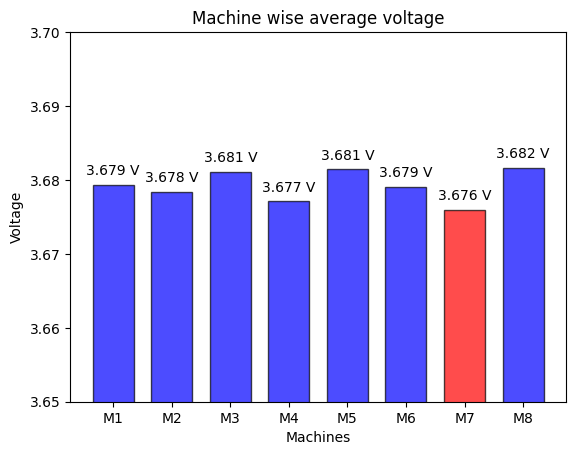

In [181]:
import matplotlib.pyplot as plt
average_voltage_of_machines=data_production.groupby('Machine').agg(Average_voltage=('Voltage','mean')).reset_index()
print(average_voltage_of_machines)
min_voltage=average_voltage_of_machines['Average_voltage'].min()
colors=['red' if voltage== min_voltage else  'blue'
        for voltage in average_voltage_of_machines['Average_voltage']]
fig,ax1=plt.subplots()
bars=ax1.bar(average_voltage_of_machines['Machine'],average_voltage_of_machines['Average_voltage'],
        color=colors,alpha=0.7,width=0.7,edgecolor='black')
ax1.bar_label(bars,
              fmt='%.3f V',
              padding=5)
ax1.set_ylim(3.650,3.7)
ax1.set_title('Machine wise average voltage')
ax1.set_xlabel('Machines')
ax1.set_ylabel('Voltage')

               Average_Voltage
Machine Shift                 
M1      Day           3.681062
        Night         3.676773
M2      Day           3.682606
        Night         3.673800


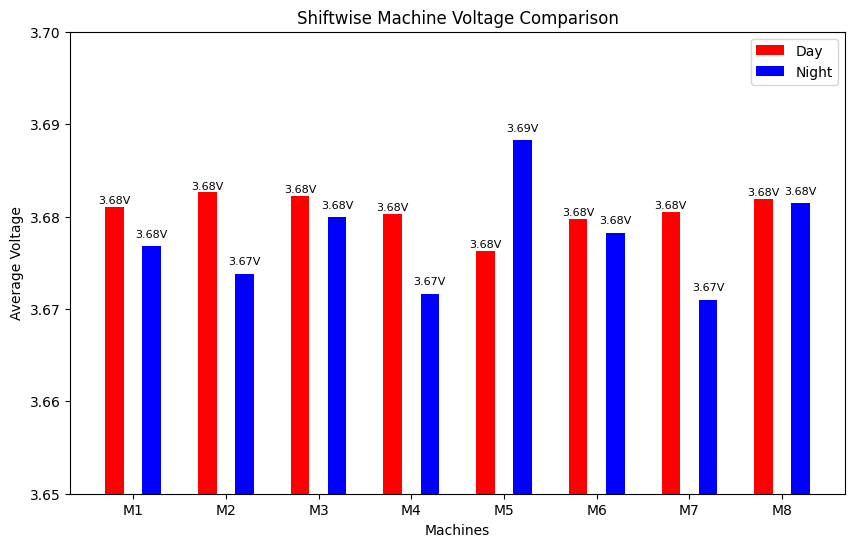

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
shift_wise_production_machine=data_production.groupby(['Machine','Shift']).agg(Average_Voltage=('Voltage','mean'))
print(shift_wise_production_machine.head(4))
pivot_table_machine_shift=data_production.pivot_table(index='Machine',
                                                      columns='Shift',
                                                      values='Voltage',
                                                      aggfunc='mean')
shift_day_machine_voltage=pivot_table_machine_shift['Day']
shift_night_machine_voltage=pivot_table_machine_shift['Night']
machines=pivot_table_machine_shift.index
x=np.arange(len(machines))
bar1_positions=x-0.2
bar2_position=x+0.2


fig,ax=plt.subplots(figsize=(10,6))

bars_1=ax.bar(bar1_positions,shift_day_machine_voltage,color='r',width=0.2)
ax.bar_label(bars_1,
             fmt='%.2fV',
             fontsize=8,
             padding=1)
bars_2=ax.bar(bar2_position,shift_night_machine_voltage,color='b',width=0.2)
ax.bar_label(bars_2,
             fmt='%.2fV',
             fontsize=8,
             padding=5)
ax.set_xticks(x)
ax.set_xticklabels(machines)
ax.set_xlabel('Machines')
ax.set_ylabel('Average Voltage')
ax.set_ylim(3.650,3.700)
ax.set_title('Shiftwise Machine Voltage Comparison')
ax.legend(pivot_table_machine_shift.columns)

import matplotlib.pyplot as plt
import numpy as np
shift_wise_production_machine=data_production.groupby(['Machine','Shift']).agg(Average_Voltage=('Voltage','mean'))
print(shift_wise_production_machine.head(4))
pivot_table_machine_shift=data_production.pivot_table(index='Machine',
                                                      columns='Shift',
                                                      values='Voltage',
                                                      aggfunc='mean')
shift_day_machine_voltage=pivot_table_machine_shift['Day']
shift_night_machine_voltage=pivot_table_machine_shift['Night']
machines=pivot_table_machine_shift.index
x=np.arange(len(machines))
bar1_positions=x-0.2
bar2_position=x+0.2


fig,ax=plt.subplots(figsize=(10,6))

bars_1=ax.bar(bar1_positions,shift_day_machine_voltage,color='r',width=0.2)
ax.bar_label(bars_1,
             fmt='%.2fV',
             fontsize=8,
             padding=1)
bars_2=ax.bar(bar2_position,shift_night_machine_voltage,color='b',width=0.2)
ax.bar_label(bars_2,
             fmt='%.2fV',
             fontsize=8,
             padding=5)
ax.set_xticks(x)
ax.set_xticklabels(machines)
ax.set_xlabel('Machines')
ax.set_ylabel('Average Voltage')
ax.set_ylim(3.650,3.700)
ax.set_title('Shiftwise Machine Voltage Comparison')
ax.legend(pivot_table_machine_shift.columns)







